# Smart Product Categorization System

This notebook consolidates the entire project for training in Google Colab.

**Categories:** `beverage`, `snack`

**Architecture:** EfficientNet-B0 / ResNet-18 / MobileNet-V2 / SimpleCNN

## 0. Install Dependencies & Mount Drive

In [ ]:
!pip install -q torch torchvision scikit-learn matplotlib pandas Pillow tqdm huggingface-hub python-dotenv

In [ ]:
# Optional: Mount Google Drive if you want persistent storage
# from google.colab import drive
# drive.mount('/content/drive')

## 1. Configuration

In [ ]:
import os
import re
import csv
import json
import random
import tarfile
import argparse
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from pathlib import Path
from typing import (
    Callable, Dict, Iterable, List, Optional, Tuple, Union, Literal,
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    ResNet18_Weights,
    MobileNet_V2_Weights,
)
from PIL import Image
from tqdm import tqdm
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, default_data_collator
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from huggingface_hub import hf_hub_download
except ImportError:
    print("huggingface_hub not installed — manual data upload required.")

In [ ]:
# ─── Set your Hugging Face token here ─────────────────────────────────────────
# Option 1: paste directly
HF_TOKEN = ""  # <-- paste your token or leave empty

# Option 2: use Colab secrets
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("HF_TOKEN set ✓")
else:
    print("⚠️  No HF_TOKEN found. Set it above or upload data manually.")

⚠️  No HF_TOKEN found. Set it above or upload data manually.


## 2. Data Config

In [ ]:
@dataclass
class DataConfig:
    repo_id: str = "Phathanan/product-categorization-system"
    repo_type: str = "dataset"
    raw_tar_in_repo: str = "data/raw/data_v2.tar"
    token: Optional[str] = None
    revision: Optional[str] = None

    dataset_dir: Path = Path("data_local")
    raw_extract_dirname: str = "raw_extracted"
    processed_dirname: str = "processed"
    raw_metadata_name: str = "metadata.csv"

    labels: List[str] = field(
        default_factory=lambda: ["beverage", "snack"]
    )
    dedup_by_barcode: bool = False
    cap_per_label: Optional[int] = None

    min_side: int = 128
    do_verify: bool = False
    num_workers: int = 8

    seed: int = 42
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

    def paths(self) -> dict:
        tar_stem = Path(self.raw_tar_in_repo).name
        if tar_stem.endswith(".tar"):
            tar_stem = tar_stem[:-4]
        else:
            tar_stem = Path(tar_stem).stem

        raw_dir = self.dataset_dir / self.raw_extract_dirname / tar_stem
        proc_dir = self.dataset_dir / self.processed_dirname / tar_stem

        return {
            "raw_dir": raw_dir,
            "proc_dir": proc_dir,
            "raw_metadata": raw_dir / self.raw_metadata_name,
            "manifest_clean": proc_dir / "manifest_clean.csv",
            "splits": proc_dir / "splits.json",
            "stats": proc_dir / "stats.json",
            "label_map": proc_dir / "label_map.json",
        }

## 3. Train Config

In [ ]:
@dataclass
class TrainConfig:
    model_name: str = "resnet50"
    freeze_backbone: bool = True
    dropout: float = 0.3

    manifest: Path = Path("data_local/processed/data_v2/manifest_clean.csv")
    label_map: Path = Path("data_local/processed/data_v2/label_map.json")

    epochs: int = 20
    batch_size: int = 32
    num_workers: int = 2
    lr: float = 1e-3
    weight_decay: float = 1e-4

    lr_scheduler: str = "cosine"
    lr_step_size: int = 7
    lr_gamma: float = 0.1

    image_size: int = 224

    output_dir: Path = Path("runs")

    seed: int = 42
    device: Optional[str] = None

    def run_dir(self) -> Path:
        d = self.output_dir / self.model_name
        d.mkdir(parents=True, exist_ok=True)
        return d

## 4. Data Utilities — Loader, Prepare, Validate, Split, Stats

In [ ]:
# ─── loader.py ────────────────────────────────────────────────────────────────

def _extract_tar(tar_path: Path, out_dir: Path) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    base = out_dir.resolve()
    with tarfile.open(tar_path, "r:*") as tf:
        members = tf.getmembers()
        for m in members:
            target = (out_dir / m.name).resolve()
            if not str(target).startswith(str(base)):
                raise RuntimeError(f"Unsafe path in tar: {m.name}")
        tf.extractall(out_dir)


def download_raw_tar(
    repo_id: str,
    path_in_repo: str,
    repo_type: str = "dataset",
    revision: Optional[str] = None,
    token: Optional[str] = None,
) -> Path:
    return Path(
        hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type=repo_type,
            revision=revision,
            token=token,
        )
    )


def ensure_extracted(raw_tar: Path, extract_dir: Path) -> None:
    marker = extract_dir / ".extracted.ok"
    if marker.exists():
        return
    extract_dir.mkdir(parents=True, exist_ok=True)
    _extract_tar(raw_tar, extract_dir)
    marker.write_text("ok", encoding="utf-8")

In [ ]:
# ─── prepare.py ───────────────────────────────────────────────────────────────

def norm_barcode(x: object) -> str:
    s = re.sub(r"\D", "", str(x or ""))
    return s.zfill(13) if s else ""


def load_metadata(meta_path: Path) -> pd.DataFrame:
    df = pd.read_csv(meta_path)
    return df


def add_paths(df: pd.DataFrame, raw_dir: Path) -> pd.DataFrame:
    raw_dir = Path(raw_dir)
    images_dir = raw_dir / "images"
    if not images_dir.exists():
        images_dir = raw_dir

    df = df.copy()
    df["barcode"] = df["barcode"].map(norm_barcode)
    df["image_id"] = df["image_id"].astype("string").fillna("").str.strip()

    rel = (
        df["image_id"]
        .str.replace("/", os.sep, regex=False)
        .str.lstrip("\\/")
    )

    df["abs_path"] = rel.map(lambda r: str(images_dir / r))

    return df


def basic_clean(
    df: pd.DataFrame,
    labels: Optional[list] = None,
    dedup_by_barcode: bool = True,
    cap_per_label: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    df = df.copy()

    if "label_coarse" not in df.columns:
        raise ValueError("metadata must contain label_coarse")

    df["label_coarse"] = df["label_coarse"].astype(str).str.strip()

    def remap_label(lbl: str) -> str:
        lbl = str(lbl).lower()
        if lbl in ["snacks", "snack"]: return "snack"
        if lbl in ["beverages", "beverage"]: return "beverage"
        return lbl

    df["label_coarse"] = df["label_coarse"].apply(remap_label)
    df = df[df["barcode"].astype(str).str.len() > 0]
    df = df[df["image_id"].astype(str).str.len() > 0]
    df = df[df["abs_path"].astype(str).str.len() > 0]

    if labels:
        df = df[df["label_coarse"].isin(labels)]

    df = df.drop_duplicates(subset=["abs_path"], keep="first")

    if dedup_by_barcode:
        df = df.sort_values(["barcode", "label_coarse", "image_id"])
        df = df.drop_duplicates(subset=["barcode"], keep="first")

    if cap_per_label is not None:
        rng = np.random.default_rng(seed)
        kept = []
        for lbl, g in df.groupby("label_coarse"):
            if len(g) <= cap_per_label:
                kept.append(g)
            else:
                idx = rng.choice(g.index.to_numpy(), size=cap_per_label, replace=False)
                kept.append(df.loc[idx])
        df = pd.concat(kept, ignore_index=True)

    df = df.reset_index(drop=True)
    return df


def attach_label_map(labels: list) -> dict:
    return {lbl: i for i, lbl in enumerate(labels)}

In [ ]:
# ─── validate.py ──────────────────────────────────────────────────────────────

def _check_one(path: str, min_side: int, do_verify: bool) -> Tuple[int, int, int, int]:
    p = Path(path)
    if not p.exists():
        return 0, 0, 0, 0
    try:
        if do_verify:
            with Image.open(p) as im:
                im.verify()
        with Image.open(p) as im:
            w, h = im.size
        ok = int(min(w, h) >= min_side)
        size = int(p.stat().st_size)
        return ok, w, h, size
    except Exception:
        return 0, 0, 0, 0


def validate_images(
    df: pd.DataFrame,
    min_side: int = 128,
    do_verify: bool = False,
    num_workers: int = 8,
) -> pd.DataFrame:
    if "abs_path" not in df.columns:
        raise ValueError("df must contain abs_path")

    paths = df["abs_path"].astype(str).tolist()
    results = [None] * len(paths)

    with ThreadPoolExecutor(max_workers=max(1, int(num_workers))) as ex:
        futs = {
            ex.submit(_check_one, paths[i], min_side, do_verify): i
            for i in range(len(paths))
        }
        for fut in tqdm(as_completed(futs), total=len(futs), desc="validate images"):
            i = futs[fut]
            results[i] = fut.result()

    out = df.copy()
    out["img_ok"] = [r[0] for r in results]
    out["w"] = [r[1] for r in results]
    out["h"] = [r[2] for r in results]
    out["file_size"] = [r[3] for r in results]
    return out


def keep_only_ok(df: pd.DataFrame) -> pd.DataFrame:
    if "img_ok" not in df.columns:
        raise ValueError("df must contain img_ok")
    return df[df["img_ok"] == 1].copy().reset_index(drop=True)

In [ ]:
# ─── split.py ─────────────────────────────────────────────────────────────────

@dataclass
class SplitConfig:
    seed: int = 42
    train_frac: float = 0.8
    val_frac: float = 0.1
    test_frac: float = 0.1


def _alloc_counts(n: int, train_f: float, val_f: float, test_f: float) -> Tuple[int, int, int]:
    if n <= 0:
        return 0, 0, 0
    if n == 1:
        return 1, 0, 0
    if n == 2:
        return 1, 1, 0
    val = max(1, int(round(n * val_f)))
    test = max(1, int(round(n * test_f)))
    if val + test >= n:
        val = 1
        test = 1
    train = n - val - test
    if train <= 0:
        train = max(1, n - 2)
        val = 1 if n - train >= 1 else 0
        test = n - train - val
    return train, val, test


def split_by_barcode(df: pd.DataFrame, cfg: SplitConfig) -> Tuple[pd.DataFrame, Dict]:
    if "barcode" not in df.columns or "label_coarse" not in df.columns:
        raise ValueError("df must contain barcode and label_coarse")

    rng = np.random.default_rng(cfg.seed)
    pairs = df[["barcode", "label_coarse"]].drop_duplicates()
    barcode_to_label = dict(zip(pairs["barcode"], pairs["label_coarse"]))

    split_map: Dict[str, str] = {}

    for lbl, g in pairs.groupby("label_coarse"):
        barcodes = g["barcode"].tolist()
        rng.shuffle(barcodes)

        n = len(barcodes)
        n_train, n_val, n_test = _alloc_counts(n, cfg.train_frac, cfg.val_frac, cfg.test_frac)

        train_ids = barcodes[:n_train]
        val_ids = barcodes[n_train: n_train + n_val]
        test_ids = barcodes[n_train + n_val: n_train + n_val + n_test]

        for b in train_ids:
            split_map[b] = "train"
        for b in val_ids:
            split_map[b] = "val"
        for b in test_ids:
            split_map[b] = "test"

    out = df.copy()
    out["split"] = out["barcode"].map(split_map).fillna("train")

    splits = {"train": [], "val": [], "test": []}
    for b, s in split_map.items():
        splits[s].append(b)

    meta = {
        "seed": cfg.seed,
        "fractions": {
            "train": cfg.train_frac,
            "val": cfg.val_frac,
            "test": cfg.test_frac,
        },
        "counts": {k: len(v) for k, v in splits.items()},
        "splits": splits,
        "barcode_label": barcode_to_label,
    }
    return out, meta


def save_splits_json(meta: Dict, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(
        json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
    )

In [ ]:
# ─── stats.py ─────────────────────────────────────────────────────────────────

def compute_stats(df: pd.DataFrame) -> Dict:
    total = int(len(df))
    by_label = (
        df["label_coarse"].value_counts().to_dict()
        if "label_coarse" in df.columns
        else {}
    )
    by_split = (
        df["split"].value_counts().to_dict() if "split" in df.columns else {}
    )

    by_label_split = {}
    if "label_coarse" in df.columns and "split" in df.columns:
        tmp = df.groupby(["label_coarse", "split"]).size().reset_index(name="n")
        for _, r in tmp.iterrows():
            lbl = r["label_coarse"]
            if lbl not in by_label_split:
                by_label_split[lbl] = {}
            by_label_split[lbl][r["split"]] = int(r["n"])

    img_ok_rate = None
    if "img_ok" in df.columns:
        img_ok_rate = float(df["img_ok"].mean()) if len(df) else 0.0

    return {
        "total": total,
        "by_label": {k: int(v) for k, v in by_label.items()},
        "by_split": {k: int(v) for k, v in by_split.items()},
        "by_label_split": by_label_split,
        "img_ok_rate": img_ok_rate,
    }


def save_stats(stats: Dict, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(
        json.dumps(stats, ensure_ascii=False, indent=2), encoding="utf-8"
    )

## 5. Transforms

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_train_transforms(size: int = 224) -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize(size + 32),
            transforms.RandomResizedCrop(
                size,
                scale=(0.7, 1.0),
                ratio=(0.75, 1.33),
                interpolation=transforms.InterpolationMode.BILINEAR,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )


def get_val_transforms(size: int = 224) -> transforms.Compose:
    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )

## 6. Dataset

In [ ]:
class ProductDataset(Dataset):
    """
    PyTorch Dataset for product package image classification.

    Parameters
    ----------
    manifest : pd.DataFrame | Path | str
        Either a pre-loaded DataFrame or a path to manifest_clean.csv.
        The DataFrame must contain columns: ``abs_path``, ``label_coarse``.
    label_map : Dict[str, int] | Path | str
        Either a pre-built {class_name: int} dict or a path to label_map.json.
    split : str | None
        If not None, filter the manifest to rows where ``split == split``.
        Typical values: ``"train"``, ``"val"``, ``"test"``.
    transform : Callable | None
        torchvision transform pipeline applied to the PIL image.
        Use ``get_train_transforms()`` / ``get_val_transforms()`` from transforms.py.

    Returns  (via __getitem__)
    -------
    dict with keys:
      "pixel_values" : torch.FloatTensor  shape (C, H, W) after transform
      "labels"       : torch.LongTensor   scalar integer class index
    """

    def __init__(
        self,
        manifest: Union[pd.DataFrame, Path, str],
        label_map: Union[Dict[str, int], Path, str],
        split: Optional[str] = None,
        transform: Optional[Callable] = None,
    ) -> None:
        # ── 1. Load manifest ──────────────────────────────────────────────
        manifest_path = manifest if isinstance(manifest, (str, Path)) else None
        if isinstance(manifest, (str, Path)):
            manifest = pd.read_csv(manifest)

        if "abs_path" not in manifest.columns:
            raise ValueError("manifest must contain column 'abs_path'")
        if "label_coarse" not in manifest.columns:
            raise ValueError("manifest must contain column 'label_coarse'")


        # ── 1a. Remap and Filter to 2 classes ("snack", "beverage") ─────────────
        def remap_label(lbl: str) -> str:
            lbl = str(lbl).lower().strip()
            if lbl in ["snacks", "snack"]: return "snack"
            if lbl in ["beverages", "beverage"]: return "beverage"
            return lbl

        manifest["label_coarse"] = manifest["label_coarse"].apply(remap_label)
        manifest = manifest[manifest["label_coarse"].isin(["snack", "beverage"])].copy()

        # ── 1b. Filter out corrupted images ───────────────────────────────

        # ── 2. Filter by split ────────────────────────────────────────────
        if split is not None:
            if "split" not in manifest.columns:
                if manifest_path is not None:
                    splits_path = Path(manifest_path).parent / "splits.json"
                    if splits_path.exists():
                        splits_data = json.loads(splits_path.read_text(encoding="utf-8"))
                        barcodes = set(splits_data.get("splits", {}).get(split, []))

                        # We need 'barcode' as a string without '.0' etc
                        # Pandas sometimes reads big numbers as float if there are NaNs
                        manifest["_tmp_bc"] = manifest.get("barcode", "").astype(str).str.replace(r"\.0$", "", regex=True)
                        manifest = manifest[manifest["_tmp_bc"].isin(barcodes)].copy()
                        manifest = manifest.drop(columns=["_tmp_bc"])
                    else:
                        raise ValueError(f"split '{split}' requested, no 'split' column, and no splits.json found at {splits_path}")
                else:
                    raise ValueError(
                        f"split='{split}' requested but manifest has no 'split' column. "
                        "Run scripts/prepare_dataset.py first."
                    )
            else:
                manifest = manifest[manifest["split"] == split].copy()

            if len(manifest) == 0:
                raise ValueError(
                    f"No rows found for split='{split}'. "
                    "Check that prepare_dataset.py completed successfully."
                )

        self._df = manifest.reset_index(drop=True)

        # ── 3. Load label_map ─────────────────────────────────────────────
        # Ignore external label map and enforce 2 classes
        self._label_map: Dict[str, int] = {"beverage": 0, "snack": 1}

        # Pre-validate that every label in manifest is known
        unknown = set(self._df["label_coarse"].unique()) - set(self._label_map.keys())
        if unknown:
            raise ValueError(
                f"Labels found in manifest but missing from label_map: {unknown}"
            )

        self.transform = transform
        self.classes: list = sorted(self._label_map, key=self._label_map.get)  # type: ignore[arg-type]
        self.num_classes: int = len(self._label_map)

    # ── Dataset protocol ──────────────────────────────────────────────────

    def __len__(self) -> int:
        return len(self._df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self._df.iloc[idx]

        # ── Load image (PIL, RGB) ────────────────────────────────────────
        img_path = Path(str(row["abs_path"]))
        try:
            image: Image.Image = Image.open(img_path).convert("RGB")
        except Exception as exc:
            raise RuntimeError(
                f"Cannot open image at index {idx}: {img_path}"
            ) from exc

        # ── Apply transform pipeline ─────────────────────────────────────
        if self.transform is not None:
            image = self.transform(image)
        else:
            # Fallback: at minimum convert PIL → tensor if no transform supplied
            from torchvision.transforms.functional import to_tensor
            image = to_tensor(image)  # type: ignore[assignment]

        # ── Encode label ─────────────────────────────────────────────────
        label_int: int = self._label_map[row["label_coarse"]]
        label = torch.tensor(label_int, dtype=torch.long)

        return {"pixel_values": image, "labels": label}

    # ── Convenience helpers ───────────────────────────────────────────────

    def __repr__(self) -> str:
        return (
            f"ProductDataset("
            f"n={len(self)}, "
            f"split={self._df['split'].unique().tolist() if 'split' in self._df.columns else 'N/A'}, "
            f"classes={self.classes}"
            f")"
        )

    @property
    def label_map(self) -> Dict[str, int]:
        return dict(self._label_map)


# ── Convenience factory ───────────────────────────────────────────────────────

def build_datasets(
    manifest_path: Union[Path, str],
    label_map_path: Union[Path, str],
    train_transform: Optional[Callable] = None,
    val_transform: Optional[Callable] = None,
) -> Dict[str, "ProductDataset"]:
    """
    Build train / val / test datasets in one call.

    Example
    -------
    >>> from src.data.transforms import get_train_transforms, get_val_transforms
    >>> from src.config.data_config import DataConfig
    >>> cfg = DataConfig()
    >>> p = cfg.paths()
    >>> datasets = build_datasets(
    ...     p["manifest_clean"], p["label_map"],
    ...     train_transform=get_train_transforms(),
    ...     val_transform=get_val_transforms(),
    ... )
    >>> datasets["train"], datasets["val"], datasets["test"]
    """
    manifest = pd.read_csv(manifest_path)

    if "split" not in manifest.columns:
        splits_path = Path(manifest_path).parent / "splits.json"
        if splits_path.exists():
            splits_data = json.loads(splits_path.read_text(encoding="utf-8"))
            barcode_to_split = {}
            for sp, bcs in splits_data.get("splits", {}).items():
                for bc in bcs:
                    barcode_to_split[str(bc)] = sp

            manifest["_tmp_bc"] = manifest.get("barcode", "").astype(str).str.replace(r"\.0$", "", regex=True)
            manifest["split"] = manifest["_tmp_bc"].map(barcode_to_split)
            manifest = manifest.drop(columns=["_tmp_bc"])
            manifest = manifest.dropna(subset=["split"])

    label_map = {"beverage": 0, "snack": 1}

    ds: Dict[str, ProductDataset] = {}
    for split_name in ("train", "val", "test"):
        transform = train_transform if split_name == "train" else val_transform
        ds[split_name] = ProductDataset(
            manifest=manifest,
            label_map=label_map,
            split=split_name,
            transform=transform,
        )
    return ds

## 7. Models

In [ ]:
# ─── ProductClassifier (EfficientNet-B0) ──────────────────────────────────────

class ProductClassifier(nn.Module):
    BACKBONE_OUT_FEATURES: int = 1280

    def __init__(
        self,
        num_classes: int = 4,
        freeze_backbone: bool = True,
        dropout: float = 0.3,
        pretrained: bool = True,
    ) -> None:
        super().__init__()

        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.efficientnet_b0(weights=weights)

        self.backbone: nn.Module = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(self.BACKBONE_OUT_FEATURES, num_classes),
        )

        nn.init.xavier_uniform_(self.head[2].weight)
        nn.init.zeros_(self.head[2].bias)

        self.num_classes = num_classes
        self._backbone_frozen = False

        if freeze_backbone:
            self.freeze_backbone()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.pool(x)
        x = self.head(x)
        return x

    def freeze_backbone(self) -> None:
        for param in self.backbone.parameters():
            param.requires_grad = False
        self._backbone_frozen = True

    def unfreeze_backbone(self) -> None:
        for param in self.backbone.parameters():
            param.requires_grad = True
        self._backbone_frozen = False

    def unfreeze_last_n_blocks(self, n: int = 3) -> None:
        blocks = list(self.backbone.children())
        for block in blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True

    def trainable_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def param_summary(self) -> Dict[str, int]:
        total = self.total_params()
        trainable = self.trainable_params()
        return {"total": total, "trainable": trainable, "frozen": total - trainable}

    def save(self, path: Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(
            {
                "model_state_dict": self.state_dict(),
                "num_classes": self.num_classes,
            },
            path,
        )

    @classmethod
    def load(cls, path: Path, num_classes: Optional[int] = None, map_location: str = "cpu") -> "ProductClassifier":
        ckpt = torch.load(path, map_location=map_location)
        nc = num_classes or ckpt["num_classes"]
        model = cls(num_classes=nc, freeze_backbone=False, pretrained=False)
        model.load_state_dict(ckpt["model_state_dict"])
        return model

    def __repr__(self) -> str:
        return (
            f"ProductClassifier("
            f"backbone=EfficientNet-B0, "
            f"num_classes={self.num_classes}, "
            f"frozen={self._backbone_frozen}, "
            f"trainable_params={self.trainable_params():,})"
        )

In [ ]:
# ─── SimpleCNN ────────────────────────────────────────────────────────────────

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 4, dropout: float = 0.3) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
        )

        self.num_classes = num_classes
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

    def freeze_backbone(self) -> None:
        pass

    def unfreeze_backbone(self) -> None:
        pass

    def trainable_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def param_summary(self) -> dict:
        total = self.total_params()
        trainable = self.trainable_params()
        return {"total": total, "trainable": trainable, "frozen": total - trainable}

    def save(self, path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(
            {"model_state_dict": self.state_dict(), "num_classes": self.num_classes},
            path,
        )

    def __repr__(self) -> str:
        return f"SimpleCNN(num_classes={self.num_classes}, trainable_params={self.trainable_params():,})"

In [ ]:
# ─── TransferModel wrapper (for ResNet-18 / MobileNet-V2) ────────────────────

class _TransferModel(nn.Module):
    def __init__(self, backbone: nn.Module, num_classes: int, freeze_backbone: bool) -> None:
        super().__init__()
        self._backbone = backbone
        self.num_classes = num_classes
        self._backbone_frozen = False
        if freeze_backbone:
            self.freeze_backbone()

    def forward(self, pixel_values: Optional[torch.Tensor] = None, labels: Optional[torch.Tensor] = None, x: Optional[torch.Tensor] = None):
        inputs = pixel_values if pixel_values is not None else x
        logits = self._backbone(inputs)
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
            return (loss, logits)
        return logits

    def freeze_backbone(self) -> None:
        for name, param in self._backbone.named_parameters():
            if not name.startswith("fc.") and not name.startswith("classifier."):
                param.requires_grad = False
        self._backbone_frozen = True

    def unfreeze_backbone(self) -> None:
        for param in self._backbone.parameters():
            param.requires_grad = True
        self._backbone_frozen = False

    def trainable_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def param_summary(self) -> dict:
        total = self.total_params()
        trainable = self.trainable_params()
        return {"total": total, "trainable": trainable, "frozen": total - trainable}

    def save(self, path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(
            {"model_state_dict": self.state_dict(), "num_classes": self.num_classes},
            path,
        )

    def __repr__(self) -> str:
        name = type(self._backbone).__name__
        return (
            f"{name}Wrapper("
            f"num_classes={self.num_classes}, "
            f"frozen={self._backbone_frozen}, "
            f"trainable_params={self.trainable_params():,})"
        )

In [ ]:
# ─── Model factory ────────────────────────────────────────────────────────────

def _build_resnet50(num_classes: int, freeze_backbone: bool, dropout: float) -> _TransferModel:
    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_features = backbone.fc.in_features
    backbone.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    nn.init.xavier_uniform_(backbone.fc[1].weight)
    nn.init.zeros_(backbone.fc[1].bias)
    return _TransferModel(backbone, num_classes, freeze_backbone)


def _build_mobilenetv3_large(num_classes: int, freeze_backbone: bool, dropout: float) -> _TransferModel:
    backbone = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    in_features = backbone.classifier[-1].in_features
    backbone.classifier[-1] = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    nn.init.xavier_uniform_(backbone.classifier[-1][1].weight)
    nn.init.zeros_(backbone.classifier[-1][1].bias)
    return _TransferModel(backbone, num_classes, freeze_backbone)


def _build_mobilenetv2(num_classes: int, freeze_backbone: bool, dropout: float) -> _TransferModel:
    backbone = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    nn.init.xavier_uniform_(backbone.classifier[1].weight)
    nn.init.zeros_(backbone.classifier[1].bias)
    return _TransferModel(backbone, num_classes, freeze_backbone)


_REGISTRY = {
    "efficientnet_b0": lambda nc, fb, do: ProductClassifier(num_classes=nc, freeze_backbone=fb, dropout=do),
    "simple_cnn": lambda nc, fb, do: SimpleCNN(num_classes=nc, dropout=do),
    "resnet50": _build_resnet50,
    "mobilenetv3_large": _build_mobilenetv3_large,
}

ModelName = Literal["efficientnet_b0", "simple_cnn", "resnet50", "mobilenetv3_large"]


def build_model(
    name: str,
    num_classes: int = 4,
    freeze_backbone: bool = True,
    dropout: float = 0.3,
) -> nn.Module:
    name = name.lower().strip()
    if name not in _REGISTRY:
        raise ValueError(
            f"Unknown model '{name}'. Choose from: {list(_REGISTRY.keys())}"
        )
    return _REGISTRY[name](num_classes, freeze_backbone, dropout)


def available_models() -> list:
    return list(_REGISTRY.keys())

## 8. Metrics & Logger

In [ ]:
# ─── metrics.py ───────────────────────────────────────────────────────────────

def compute_metrics(
    all_labels: List[int],
    all_preds: List[int],
    class_names: Optional[List[str]] = None,
) -> Dict[str, float]:
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    acc = float(accuracy_score(y_true, y_pred))
    labels_arg = list(range(len(class_names))) if class_names is not None else None
    f1_macro = float(f1_score(y_true, y_pred, labels=labels_arg, average="macro", zero_division=0))

    result: Dict[str, float] = {
        "accuracy": acc,
        "f1_macro": f1_macro,
    }

    if class_names:
        per_class = f1_score(y_true, y_pred, labels=labels_arg, average=None, zero_division=0)
        for name, score in zip(class_names, per_class):
            result[f"f1_{name}"] = float(score)

    return result


def get_classification_report(
    all_labels: List[int],
    all_preds: List[int],
    class_names: Optional[List[str]] = None,
) -> str:
    labels_arg = list(range(len(class_names))) if class_names is not None else None
    return classification_report(
        all_labels, all_preds, labels=labels_arg, target_names=class_names, zero_division=0
    )


def get_confusion_matrix(
    all_labels: List[int],
    all_preds: List[int],
    class_names: Optional[List[str]] = None,
) -> np.ndarray:
    labels_arg = list(range(len(class_names))) if class_names is not None else None
    return confusion_matrix(all_labels, all_preds, labels=labels_arg)

In [ ]:
# ─── logger.py ────────────────────────────────────────────────────────────────

class CSVLogger:
    def __init__(self, path: Path) -> None:
        self.path = Path(path)
        self._header_written = self.path.exists()

    def log(self, epoch: int, split: str, **metrics: float) -> None:
        row = {"epoch": epoch, "split": split, **metrics}
        write_header = not self._header_written
        with self.path.open("a", newline="") as fh:
            writer = csv.DictWriter(fh, fieldnames=list(row.keys()))
            if write_header:
                writer.writeheader()
                self._header_written = True
            writer.writerow(row)


def _read_csv(path: Path) -> List[Dict]:
    with path.open() as fh:
        return list(csv.DictReader(fh))


def plot_loss_curves(csv_path: Path, out_path: Path) -> None:
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("[logger] matplotlib not installed — skipping loss curve plot.")
        return

    rows = _read_csv(csv_path)
    train_rows = [r for r in rows if r["split"] == "train"]
    val_rows = [r for r in rows if r["split"] == "val"]

    if not train_rows or not val_rows:
        return

    epochs = [int(r["epoch"]) for r in train_rows]
    train_loss = [float(r["loss"]) for r in train_rows]
    val_loss = [float(r["loss"]) for r in val_rows]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, train_loss, label="train_loss", marker="o", markersize=3)
    ax.plot(epochs, val_loss, label="val_loss", marker="s", markersize=3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Train vs Val Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)


def plot_accuracy_curve(csv_path: Path, out_path: Path) -> None:
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("[logger] matplotlib not installed — skipping accuracy curve plot.")
        return

    rows = _read_csv(csv_path)
    val_rows = [r for r in rows if r["split"] == "val"]

    if not val_rows:
        return

    epochs = [int(r["epoch"]) for r in val_rows]
    accuracy = [float(r["accuracy"]) for r in val_rows]
    f1 = [float(r["f1_macro"]) for r in val_rows]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, accuracy, label="val_accuracy", marker="o", markersize=3)
    ax.plot(epochs, f1, label="val_f1_macro", marker="s", markersize=3)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title("Val Accuracy & F1-Macro")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)


def plot_confusion_matrix(
    cm: np.ndarray,
    class_names: List[str],
    out_path: Path,
    title: str = "Confusion Matrix",
) -> None:
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("[logger] matplotlib not installed — skipping confusion matrix plot.")
        return

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set(
        xticks=range(len(class_names)),
        yticks=range(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.close(fig)

## 9. Trainer

In [ ]:
def get_next_run_dir(base_dir: Path, model_name: str) -> Path:
    base_dir.mkdir(parents=True, exist_ok=True)
    existing_tests = []
    pattern = re.compile(rf"^{model_name}_test(\d+)$")
    for item in base_dir.iterdir():
        if item.is_dir():
            match = pattern.match(item.name)
            if match:
                existing_tests.append(int(match.group(1)))
    next_num = max(existing_tests) + 1 if existing_tests else 1
    return base_dir / f"{model_name}_test{next_num}"

# HF compute metrics
def compute_metrics_hf(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    preds = np.argmax(predictions, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1_macro": f1}


## 10. Data Preparation Pipeline

In [ ]:
def prepare_data(data_cfg: Optional[DataConfig] = None) -> dict:
    """Run the full data preparation pipeline. Returns the paths dict."""
    if data_cfg is None:
        data_cfg = DataConfig()

    # Use HF_TOKEN from environment if not set
    if data_cfg.token is None:
        data_cfg.token = os.environ.get("HF_TOKEN")

    p = data_cfg.paths()
    p["raw_dir"].mkdir(parents=True, exist_ok=True)
    p["proc_dir"].mkdir(parents=True, exist_ok=True)

    # Check if already prepared
    if p["manifest_clean"].exists() and p["label_map"].exists():
        print("✓ Data already prepared. Skipping download & processing.")
        return p

    print("Downloading raw tar from Hugging Face …")
    raw_tar = download_raw_tar(
        repo_id=data_cfg.repo_id,
        path_in_repo=data_cfg.raw_tar_in_repo,
        repo_type=data_cfg.repo_type,
        revision=data_cfg.revision,
        token=data_cfg.token,
    )

    print("Extracting …")
    ensure_extracted(raw_tar, p["raw_dir"])

    if not p["raw_metadata"].exists():
        raise FileNotFoundError(f"metadata.csv not found at {p['raw_metadata']}")

    print("Loading metadata …")
    df = load_metadata(p["raw_metadata"])
    df = add_paths(df, p["raw_dir"])

    print("Cleaning …")
    df = basic_clean(
        df,
        labels=data_cfg.labels,
        dedup_by_barcode=data_cfg.dedup_by_barcode,
        cap_per_label=data_cfg.cap_per_label,
        seed=data_cfg.seed,
    )

    print("Validating images …")
    df = validate_images(
        df,
        min_side=data_cfg.min_side,
        do_verify=data_cfg.do_verify,
        num_workers=data_cfg.num_workers,
    )
    df = keep_only_ok(df)

    print("Splitting by barcode …")
    split_cfg = SplitConfig(
        seed=data_cfg.seed,
        train_frac=data_cfg.train_frac,
        val_frac=data_cfg.val_frac,
        test_frac=data_cfg.test_frac,
    )
    df, split_meta = split_by_barcode(df, split_cfg)

    # Save outputs
    df.to_csv(p["manifest_clean"], index=False)
    save_splits_json(split_meta, p["splits"])

    label_map = attach_label_map(data_cfg.labels)
    p["label_map"].write_text(
        json.dumps(label_map, ensure_ascii=False, indent=2), encoding="utf-8"
    )

    stats = compute_stats(df)
    save_stats(stats, p["stats"])

    print(f"✓ Data preparation complete!")
    print(f"  manifest : {p['manifest_clean']}")
    print(f"  label_map: {p['label_map']}")
    print(f"  stats    : {p['stats']}")

    return p

## 11. Reproducibility

In [ ]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 12. Run Data Preparation

In [ ]:
data_cfg = DataConfig()
paths = prepare_data(data_cfg)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/raw/data_v2.tar:   0%|          | 0.00/242M [00:00<?, ?B/s]

Extracting …


/tmp/ipython-input-3279711131.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(out_dir)


Loading metadata …
Cleaning …
Validating images …


validate images: 100%|██████████| 4000/4000 [00:00<00:00, 4314.26it/s]


Splitting by barcode …
✓ Data preparation complete!
  manifest : data_local/processed/data_v2/manifest_clean.csv
  label_map: data_local/processed/data_v2/label_map.json
  stats    : data_local/processed/data_v2/stats.json


## 13. Configure Training

Edit these parameters as needed:

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    TRAINING SETTINGS                        ║
# ║  Edit these values to control your experiment               ║
# ╚══════════════════════════════════════════════════════════════╝

MODEL_NAME = "mobilenetv3_large"          # "efficientnet_b0" | "resnet50" | "mobilenetv3_large" | "simple_cnn"
FREEZE_BACKBONE = True           # Stage 1: head-only training
DROPOUT = 0.3
EPOCHS = 20
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-3
LR_SCHEDULER = "cosine"         # "cosine" | "step" | "none"
IMAGE_SIZE = 224
NUM_WORKERS = 2                  # Colab typically has 2 CPUs
SEED = 42
OUTPUT_DIR = Path("outputs")

print(f"Available models: {available_models()}")
print(f"Selected model  : {MODEL_NAME}")

Available models: ['efficientnet_b0', 'simple_cnn', 'resnet50', 'mobilenetv3_large']
Selected model  : mobilenetv3_large


## 14. Train!

In [ ]:
seed_everything(SEED)

# Build config
cfg = TrainConfig(
    model_name=MODEL_NAME,
    freeze_backbone=FREEZE_BACKBONE,
    dropout=DROPOUT,
    manifest=paths["manifest_clean"],
    label_map=paths["label_map"],
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler=LR_SCHEDULER,
    image_size=IMAGE_SIZE,
    output_dir=OUTPUT_DIR,
    seed=SEED,
    device=None,  # auto-detect (will use GPU if available)
)

# Build datasets
print("Loading datasets …")
datasets = build_datasets(
    manifest_path=cfg.manifest,
    label_map_path=cfg.label_map,
    train_transform=get_train_transforms(size=cfg.image_size),
    val_transform=get_val_transforms(size=cfg.image_size),
)

train_ds = datasets["train"]
val_ds = datasets["val"]

print(f"  train : {train_ds}")
print(f"  val   : {val_ds}")

class_names = train_ds.classes
num_classes = train_ds.num_classes

# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

# Build model
print(f"Building model: {cfg.model_name} …")
model = build_model(
    name=cfg.model_name,
    num_classes=num_classes,
    freeze_backbone=cfg.freeze_backbone,
    dropout=cfg.dropout,
)

if hasattr(model, "param_summary"):
    ps = model.param_summary()
    print(f"  params  total={ps['total']:,}  trainable={ps['trainable']:,}  frozen={ps['frozen']:,}")

# ── Trainer Base Directory ────────────────────────────────────────────
run_dir = get_next_run_dir(cfg.output_dir, cfg.model_name)
print(f"\nOutput directory for this run: {run_dir}\n")


# ── Hugging Face Trainer ──────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=str(run_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=cfg.lr,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    num_train_epochs=cfg.epochs,
    weight_decay=cfg.weight_decay,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    dataloader_num_workers=cfg.num_workers,
    seed=cfg.seed,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics_hf,
    data_collator=default_data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Starting Hugging Face Trainer loop ...")
trainer.train()
import matplotlib.pyplot as plt
import numpy as np

trainer.save_model(str(run_dir / "best_model"))
with open(run_dir / "metrics.json", "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

# Extract metrics from log_history
train_epochs, train_loss = [], []
val_epochs, val_loss, val_acc, val_f1 = [], [], [], []
for log in trainer.state.log_history:
    if "loss" in log and "eval_loss" not in log:
        train_epochs.append(log["epoch"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log:
        val_epochs.append(log["epoch"])
        val_loss.append(log["eval_loss"])
        val_acc.append(log.get("eval_accuracy", 0))
        val_f1.append(log.get("eval_f1_macro", 0))

# 1. Plot Loss Curve
fig, ax = plt.subplots(figsize=(8, 5))
if train_loss: ax.plot(train_epochs, train_loss, label="train_loss", marker="o", markersize=3)
if val_loss: ax.plot(val_epochs, val_loss, label="val_loss", marker="s", markersize=3)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Train vs Val Loss")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(run_dir / "loss_curve.png", dpi=120)
plt.close(fig)

# 2. Plot Accuracy Curve
fig, ax = plt.subplots(figsize=(8, 5))
if val_acc: ax.plot(val_epochs, val_acc, label="val_accuracy", marker="o", markersize=3)
if val_f1: ax.plot(val_epochs, val_f1, label="val_f1_macro", marker="s", markersize=3)
ax.set_xlabel("Epoch"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Val Accuracy & F1-Macro")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(run_dir / "accuracy_curve.png", dpi=120)
plt.close(fig)

# 3. Generate Confusion Matrix Plot
preds_output = trainer.predict(val_ds)
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids
cm = get_confusion_matrix(y_true, y_preds, class_names)
plot_confusion_matrix(cm, class_names, run_dir / "confusion_matrix.png")

print(f"\nTraining complete! Results saved in {run_dir}")




Loading datasets …
  train : ProductDataset(n=2800, split=['train'], classes=['beverage', 'snack'])
  val   : ProductDataset(n=600, split=['val'], classes=['beverage', 'snack'])
Building model: mobilenetv3_large …
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 93.2MB/s]


  params  total=4,204,594  trainable=1,232,642  frozen=2,971,952

Output directory for this run: outputs/mobilenetv3_large_test1

Starting Hugging Face Trainer loop ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.535826,0.414278,0.815000,0.814999
2,0.422672,0.399418,0.813333,0.812865
3,0.379622,0.388333,0.826667,0.826511
4,0.373122,0.381050,0.816667,0.816373
5,0.336821,0.383943,0.815000,0.814215
6,0.320866,0.348177,0.841667,0.841539
7,0.286515,0.355093,0.845000,0.844810
8,0.276753,0.410658,0.826667,0.825251
9,0.276640,0.374793,0.836667,0.836359
10,0.237569,0.355013,0.841667,0.841613



Training complete! Results saved in outputs/mobilenetv3_large_test1


## 15. Display Training Plots

Checking for plots in outputs/mobilenetv3_large_test1 ...

loss_curve.png:


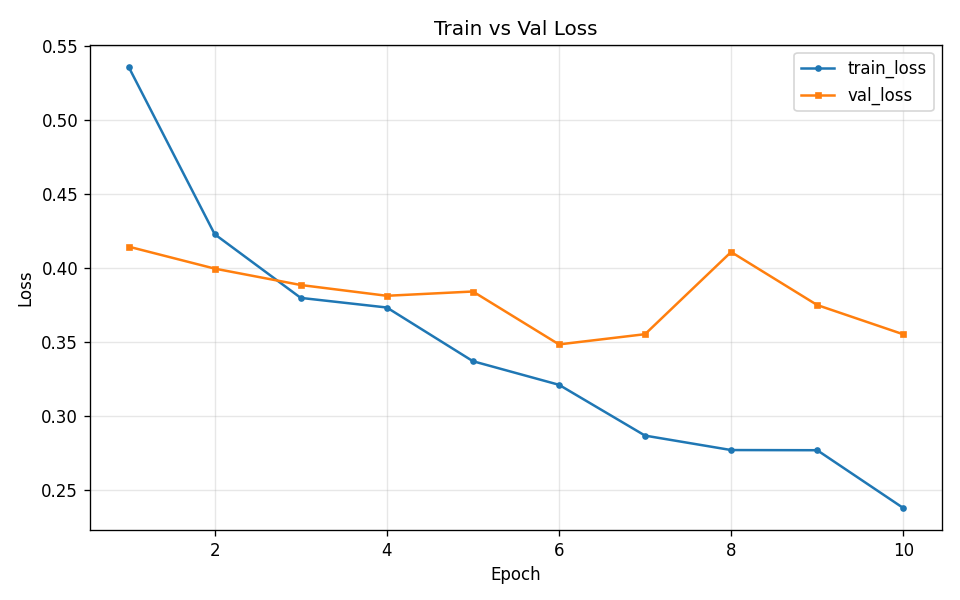


accuracy_curve.png:


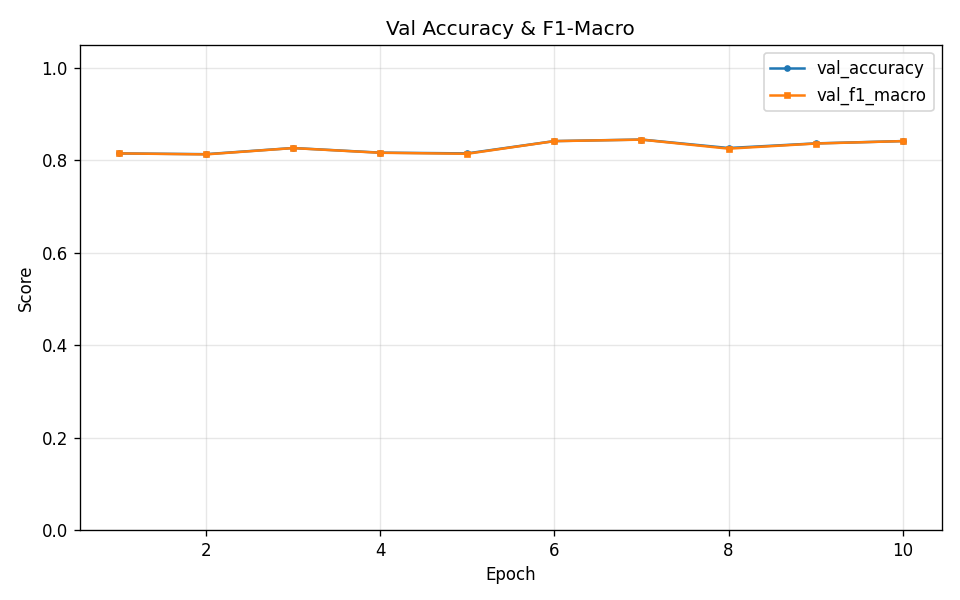


confusion_matrix.png:


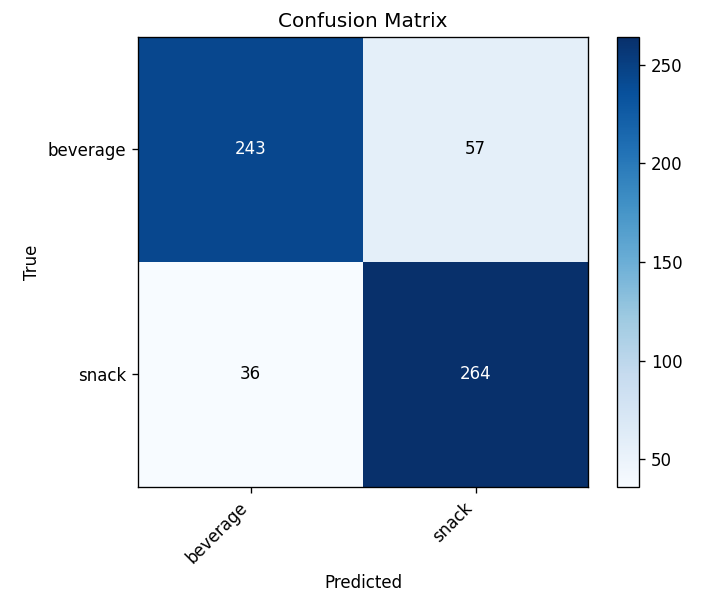

In [ ]:
from IPython.display import Image as IPImage, display
import re

# Try to use run_dir from the training cell, otherwise find the latest test run
if 'run_dir' not in globals():
    base_dir = cfg.output_dir
    model_name = cfg.model_name
    existing_tests = []
    pattern = re.compile(rf"^{model_name}_test(\d+)$")
    if base_dir.exists():
        for item in base_dir.iterdir():
            if item.is_dir():
                match = pattern.match(item.name)
                if match:
                    existing_tests.append(int(match.group(1)))

    if existing_tests:
        latest_num = max(existing_tests)
        run_dir = base_dir / f"{model_name}_test{latest_num}"
    else:
        run_dir = cfg.run_dir()

print(f"Checking for plots in {run_dir} ...")

for plot_name in ["loss_curve.png", "accuracy_curve.png", "confusion_matrix.png"]:
    plot_path = run_dir / plot_name
    if plot_path.exists():
        print(f"\n{plot_name}:")
        display(IPImage(filename=str(plot_path)))
    else:
        print(f"⚠️  {plot_name} not found")


## 16. (Optional) Test Set Evaluation

In [ ]:
test_ds = datasets["test"]
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

# Load best checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_path = run_dir / "best_model"

if best_path.exists():
    print(f"Loading best checkpoint: {best_path}")
    from transformers import PreTrainedModel
    # Wait, we can just use the model object directly if we didn't overwrite it, load_best_model implies `model` is the best
    model.to(device)
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Test"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            preds = logits.argmax(dim=1)
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

    test_metrics = compute_metrics(all_labels, all_preds, class_names)
    print(f"\n── Test Results ──")
    print(f"  Accuracy : {test_metrics['accuracy']:.4f}")
    print(f"  F1-Macro : {test_metrics['f1_macro']:.4f}")

    print(f"\n── Test Classification Report ──")
    print(get_classification_report(all_labels, all_preds, class_names))

    cm = get_confusion_matrix(all_labels, all_preds, class_names)
    plot_confusion_matrix(
        cm, class_names,
        run_dir / "test_confusion_matrix.png",
        title=f"Test Confusion Matrix — {cfg.model_name}",
    )
    display(IPImage(filename=str(run_dir / "test_confusion_matrix.png")))
else:
    print("No checkpoint found. Train the model first.")

## 17. (Optional) Download Model & Results

Uncomment to download outputs to your local machine:

In [ ]:
# from google.colab import files
#
# # Download best checkpoint
# if trainer.best_ckpt_path.exists():
#     files.download(str(trainer.best_ckpt_path))
#
# # Download metrics CSV
# csv_path = cfg.run_dir() / "metrics.csv"
# if csv_path.exists():
#     files.download(str(csv_path))
#
# # Or zip the entire outputs folder
# !zip -r outputs.zip outputs/
# files.download("outputs.zip")